In [6]:
import os
import pandas as pd
from google.cloud import bigquery
import matplotlib.pyplot as plt
import seaborn as sns

# FIX: Explicitly set the credentials to your active service account
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "C:/Users/User/Documents/Projects/vic-catch/secrets/root-anvil-474411-k5-fdd00fadc7e2.json"

# Set up the BigQuery client
client = bigquery.Client(project='root-anvil-474411-k5')

# Pull the final mart
query = """
    SELECT * FROM `root-anvil-474411-k5.vic_catch_dev.mart_precinct_score`
"""
print("Fetching data from BigQuery...")
df = client.query(query).to_dataframe()

print(f"Successfully loaded {len(df)} hexagons!")
df.head()

Fetching data from BigQuery...


C:\Users\User\Documents\Projects\vic-catch\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Successfully loaded 8725 hexagons!


,hex_id,hex_geometry,total_poi_count,cycleway_count,walkway_count,car_parking_count,retail_count,transit_stop_count,precinct_population,precinct_daily_trips,demand_proxy,supply_proxy
0,88be636089fffff,"POLYGON((144.42095572841 -37.5358525049711, 14...",0,0,0,0,0,0,0,0,0,0
1,88be63c44dfffff,"POLYGON((145.0451166719 -38.0858081216404, 145...",0,0,0,0,0,0,0,0,0,0
2,88be63d14dfffff,"POLYGON((145.436671753297 -38.1451605048462, 1...",0,0,0,0,0,0,0,0,0,0
3,88be63142dfffff,"POLYGON((144.621495646478 -38.0914200069761, 1...",0,0,0,0,0,0,0,0,0,0
4,88be6358e1fffff,"POLYGON((145.196360736569 -37.585126406919, 14...",0,0,0,0,0,0,0,0,0,0


In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Select the features that define a precinct's "vibe"
features = [
    'total_poi_count', 
    'cycleway_count', 
    'walkway_count', 
    'car_parking_count', 
    'retail_count', 
    'transit_stop_count', 
    'precinct_population', 
    'precinct_daily_trips'
]

# Create a clean dataframe for the model (dropping the hex_id and geometry for now)
X = df[features].fillna(0)

# 2. Scale the features (forces everything to have a mean of 0 and standard deviation of 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Run K-Means Clustering
# We are asking the AI to find 5 distinct types of neighborhoods
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster_id'] = kmeans.fit_predict(X_scaled)

print("Clustering complete! Here is the breakdown of how many hexes are in each cluster:")
print(df['cluster_id'].value_counts())

Clustering complete! Here is the breakdown of how many hexes are in each cluster:
cluster_id
1    6869
3    1662
0     189
2       3
4       2
Name: count, dtype: int64


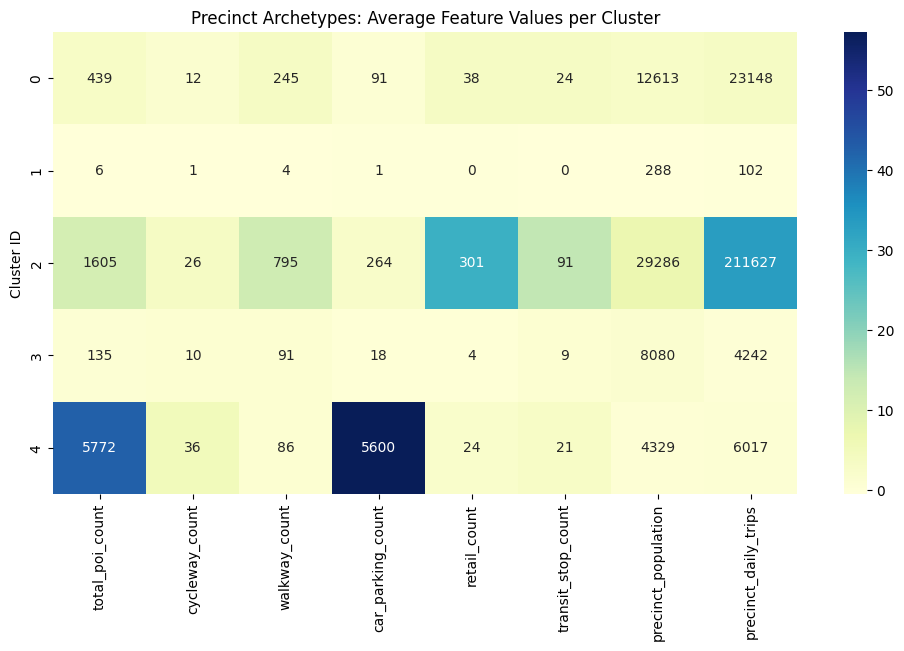

In [8]:
# Calculate the average values for each cluster
cluster_profiles = df.groupby('cluster_id')[features].mean().round(2)

# Display it as a nice heatmap so we can easily spot the differences
plt.figure(figsize=(12, 6))
sns.heatmap(scaler.transform(cluster_profiles), 
            annot=cluster_profiles.values, 
            fmt='.0f', 
            cmap='YlGnBu', 
            xticklabels=features)
plt.title("Precinct Archetypes: Average Feature Values per Cluster")
plt.ylabel("Cluster ID")
plt.show()

In [9]:
# 1. Define the Archetype dictionary based on our heatmap analysis
archetype_mapping = {
    0: "Transit-Oriented Residential",
    1: "Undeveloped / Industrial",
    2: "CBD & Metro Core",
    3: "Standard Suburbs",
    4: "Mega-Mall / Car-Heavy Retail"
}

# Apply the names to a new column
df['archetype'] = df['cluster_id'].map(archetype_mapping)

# 2. Push the final enriched data back to BigQuery
destination_table = 'root-anvil-474411-k5.vic_catch_dev.mart_precinct_archetypes'

job_config = bigquery.LoadJobConfig(
    write_disposition="WRITE_TRUNCATE", # Overwrite the table if it already exists
)

print(f"Uploading clustered precincts to {destination_table}...")
job = client.load_table_from_dataframe(df, destination_table, job_config=job_config)
job.result() # Wait for the upload to finish

print("Upload complete! The final table is ready for the dashboard.")

Uploading clustered precincts to root-anvil-474411-k5.vic_catch_dev.mart_precinct_archetypes...


C:\Users\User\Documents\Projects\vic-catch\.venv\Lib\site-packages\google\cloud\bigquery\_pandas_helpers.py:486: FutureWarning: Loading pandas DataFrame into BigQuery will require pandas-gbq package version 0.26.1 or greater in the future. Tried to import pandas-gbq and got: No module named 'pandas_gbq'
  warnings.warn(


Upload complete! The final table is ready for the dashboard.


In [10]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Define Features (X) and Target (y)
target = 'precinct_daily_trips'
predictive_features = [
    'total_poi_count', 
    'cycleway_count', 
    'walkway_count', 
    'car_parking_count', 
    'retail_count', 
    'precinct_population'
]

X = df[predictive_features].fillna(0)
y = df[target].fillna(0)

# 2. Train/Test Split (80% training, 20% testing)
# We hold back 20% of the hexagons so the model can't "cheat" during evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and Train the LightGBM Model
print("Training LightGBM Regressor...")
model = lgb.LGBMRegressor(
    n_estimators=100, 
    learning_rate=0.1, 
    random_state=42,
    force_col_wise=True # Optimizes performance for smaller datasets
)
model.fit(X_train, y_train)

# 4. Evaluate the Model
predictions = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("\n--- Model Performance ---")
print(f"R² Score: {r2:.3f} (closer to 1.0 is better)")
print(f"RMSE: {rmse:.0f} daily trips (average error margin)")

Training LightGBM Regressor...
[LightGBM] [Info] Total Bins 968
[LightGBM] [Info] Number of data points in the train set: 6980, number of used features: 6
[LightGBM] [Info] Start training from score 1472.880086

--- Model Performance ---
R² Score: 0.629 (closer to 1.0 is better)
RMSE: 3034 daily trips (average error margin)


<Figure size 1000x600 with 0 Axes>

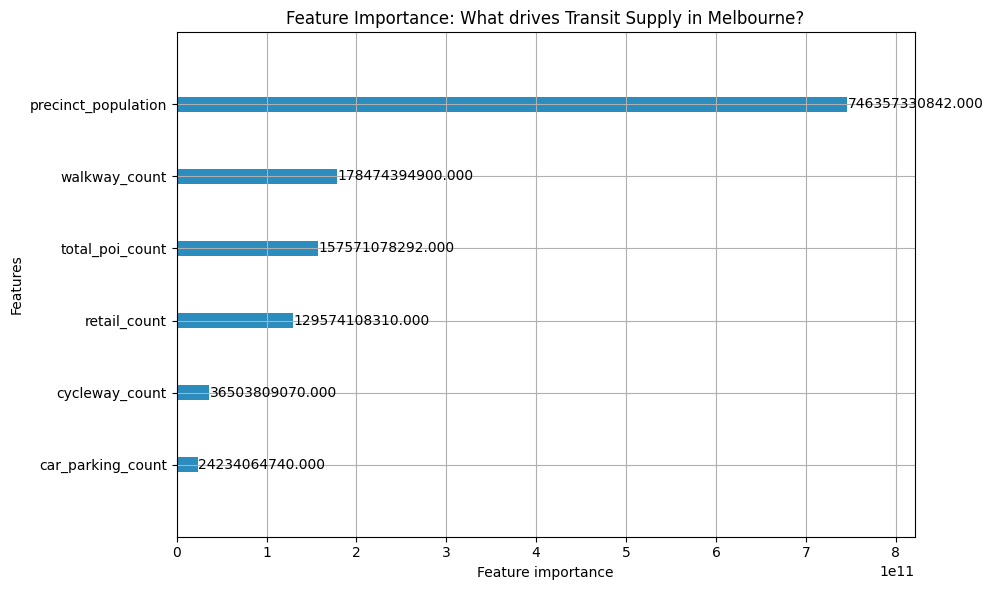

In [11]:
# 5. Business Explainability: What drives transit supply?
plt.figure(figsize=(10, 6))
lgb.plot_importance(
    model, 
    importance_type='gain', # 'gain' shows which feature actually improved the accuracy the most
    figsize=(10, 6), 
    title='Feature Importance: What drives Transit Supply in Melbourne?',
    color='#2b8cbe'
)
plt.tight_layout()
plt.show()

In [12]:
# 1. Ask LightGBM to predict the "ideal" transit supply for every precinct
df['predicted_daily_trips'] = model.predict(X)

# 2. Calculate the Opportunity Gap (Predicted Demand minus Actual Supply)
# If a precinct SHOULD have 50,000 trips but only has 10,000, the gap is +40,000 (A massive opportunity)
df['opportunity_gap'] = df['predicted_daily_trips'] - df['precinct_daily_trips']

# 3. Push this enriched data back to BigQuery (Overwriting the old table)
destination_table = 'root-anvil-474411-k5.vic_catch_dev.mart_precinct_archetypes'
job_config = bigquery.LoadJobConfig(write_disposition="WRITE_TRUNCATE")

print("Uploading LightGBM predictions to BigQuery...")
job = client.load_table_from_dataframe(df, destination_table, job_config=job_config)
job.result()
print("Success! BigQuery now has the AI predictions.")

Uploading LightGBM predictions to BigQuery...


C:\Users\User\Documents\Projects\vic-catch\.venv\Lib\site-packages\google\cloud\bigquery\_pandas_helpers.py:486: FutureWarning: Loading pandas DataFrame into BigQuery will require pandas-gbq package version 0.26.1 or greater in the future. Tried to import pandas-gbq and got: No module named 'pandas_gbq'
  warnings.warn(


Success! BigQuery now has the AI predictions.
